# Figure 3 — the dense transition

Train a block-sparse network until it stabilizes, then flip its connection
masks to all-ones so the cross-task weights become trainable. Those weights are
already exactly zero, so the flip does not change the function the network
computes — only which weights gradients can reach.

This separates two explanations for the gap in Figure 1. If dense networks
merely fail to *find* the block-sparse solution, then handing one that solution
and continuing should be harmless. It is not: performance degrades shortly
after the new connections appear, and at its own best step-size it eventually
falls below the plain dense network. That is what points at credit assignment
rather than an unlucky optimization path.

16-task multi-MNIST, 256 hidden units, one task re-permuted every 125 steps,
30 seeds. Produced by `experiments/sweeps/02_dense_transition/`.


In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from multi_mnist.analysis import (
    asymptotic_metric, fetch_per_seed_arrays, filter_sweep, filter_to_best,
    get_color_palette, load_export, normalize_columns, plot_ci_curve,
    plot_sensitivity, save_fig, set_style, stack_per_seed,
)

%matplotlib inline


In [19]:
# The Comet project the published runs live in. Change it if you
# re-run the sweeps into your own project.
PROJECT = 'paper-weight-pruning-scaling-sweep'

# Both this repository's sweep name and the names the published runs were
# logged under, so the figure regenerates from either.
SWEEP_NAMES = [
    '03_dense_transition_n16_h256',                     # this repo
    '00_block_sparse_dense_fill_main_n16_h256',         # published runs
    '00_block_sparse_dense_fill_main_n16_h256_lrext',   # its step-size addendum
]

CELL_COLS = ['task.n_tasks', 'model.initial_hidden_units',
             'algorithm.transition_step', 'seed_offset', 'optimizer.learning_rate']

# The transition step is the method axis. 600,000 exceeds total_steps, so the
# fill never fires and the run is the block-sparse baseline.
NEVER = 600_000
TRANSITION = 250_000
METHOD_LABELS = {0: 'Dense', TRANSITION: 'Dense Transition', NEVER: 'Block-Sparse'}
PALETTE = get_color_palette(classes=list(METHOD_LABELS.values()))
N_TASKS = 16


In [ ]:
# Run once to fetch from Comet, then leave commented out.
from multi_mnist.analysis import download_project
download_project(PROJECT, output_dir='data')

cfg_all, run_all = load_export(PROJECT, data_dir='data')
cfg_all = normalize_columns(cfg_all)

cfg, run = filter_sweep(cfg_all, run_all, SWEEP_NAMES, cell_cols=CELL_COLS)
run['loss_per_task'] = run['loss'] / N_TASKS
print(f'{len(cfg)} trials after dedupe')
print(cfg.groupby(['algorithm.transition_step', 'seed_offset']).size())


42 trials after dedupe
algorithm.transition_step  seed_offset
0.0                        0.0            7
                           15.0           7
250000.0                   0.0            7
                           15.0           7
600000.0                   0.0            7
                           15.0           7
dtype: int64


## Best step-size per method

In [21]:
best_cfg, best_run, best = filter_to_best(
    cfg, run, ['algorithm.transition_step'], 'accuracy', direction='max')

summary = best.copy()
summary['Method'] = summary['algorithm.transition_step'].map(METHOD_LABELS)
summary['step-size'] = summary['optimizer.learning_rate'].apply(
    lambda v: f'2^{int(np.log2(v))}')
print(summary[['Method', 'step-size', '_metric']].to_string(index=False))

assets = fetch_per_seed_arrays(best_cfg['run_id'].tolist(),
                               cache_dir='data/per_seed_cache')


          Method step-size  _metric
           Dense     2^-11 0.512681
Dense Transition     2^-10 0.479651
    Block-Sparse      2^-8 0.860443


fetch per-seed:   0%|          | 0/6 [00:00<?, ?it/s]

## Figure 3 (left) — learning curves

Four curves. Three are each method at its own best step-size. The fourth is
dense-transition run at the step-size that won for *block-sparse*, which
isolates the effect of the mask flip from any step-size re-tuning the
transition was allowed: it tracks block-sparse exactly until the flip, then
diverges within a few thousand steps.

The dotted vertical line marks the flip.


fetch per-seed:   0%|          | 0/2 [00:00<?, ?it/s]

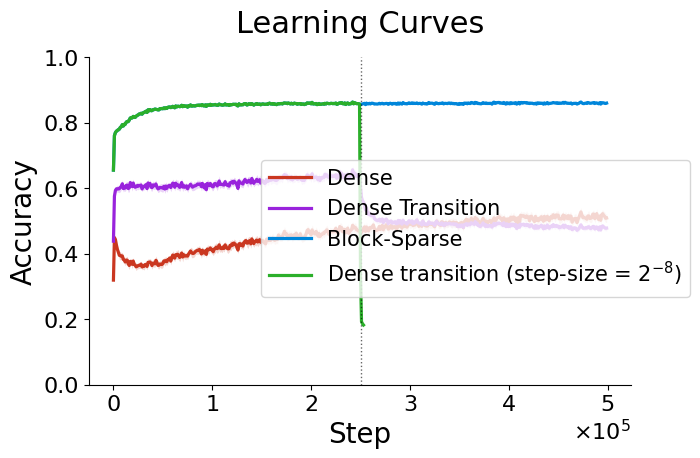

In [22]:
set_style('2-col')
fig, ax = plt.subplots()

for fill_step in sorted(best_cfg['algorithm.transition_step'].unique()):
    rids = best_cfg[best_cfg['algorithm.transition_step'] == fill_step]['run_id'].tolist()
    losses, accs = stack_per_seed(assets, rids)
    if accs is None:
        continue
    method = METHOD_LABELS[int(fill_step)]
    steps = np.arange(accs.shape[0]) * 1000
    plot_ci_curve(steps, accs, label=method, color=PALETTE[method], ax=ax)

# Dense transition at the block-sparse step-size. Numeric columns arrive from
# the CSV as objects, so coerce before comparing.
lr_bs = float(best.loc[best['algorithm.transition_step'] == NEVER,
                       'optimizer.learning_rate'].iloc[0])
cfg_lr = pd.to_numeric(cfg['optimizer.learning_rate'], errors='coerce')
cfg_ts = pd.to_numeric(cfg['algorithm.transition_step'], errors='coerce')
matched = cfg[(cfg_ts == TRANSITION) & (np.abs(cfg_lr - lr_bs) < lr_bs * 1e-6)]
matched_rids = matched['run_id'].tolist()

matched_assets = fetch_per_seed_arrays(matched_rids, cache_dir='data/per_seed_cache')
_, matched_accs = stack_per_seed(matched_assets, matched_rids)
if matched_accs is not None:
    steps = np.arange(matched_accs.shape[0]) * 1000
    plot_ci_curve(steps, matched_accs, color=get_color_palette()[2],
                  label=f'Dense transition (step-size = $2^{{{int(np.log2(lr_bs))}}}$)',
                  ax=ax)

ax.axvline(TRANSITION, linestyle=':', color='black', alpha=0.6, linewidth=1)
ax.set_xlabel('Step'); ax.set_ylabel('Accuracy')
ax.set_title('Learning Curves'); ax.set_ylim(0, 1.0)
ax.ticklabel_format(axis='x', style='sci', scilimits=(0, 0), useMathText=True)
fig.legend(loc='center right')
save_fig(fig_dir='../figures/generated', name='fig3_dense_transition_curves')
plt.show()


## Figure 3 (right) — step-size sensitivity

All three methods behave alike up to 2^-11. Block-sparse pulls ahead at 2^-10
and keeps improving past it, while dense and dense-transition diverge — they
distribute each error over more weights, so their effective step-size is larger
at the same step-size parameter, and they hit the stability limit sooner.

Dense and dense-transition diverged above 2^-10, which is why their lines stop.


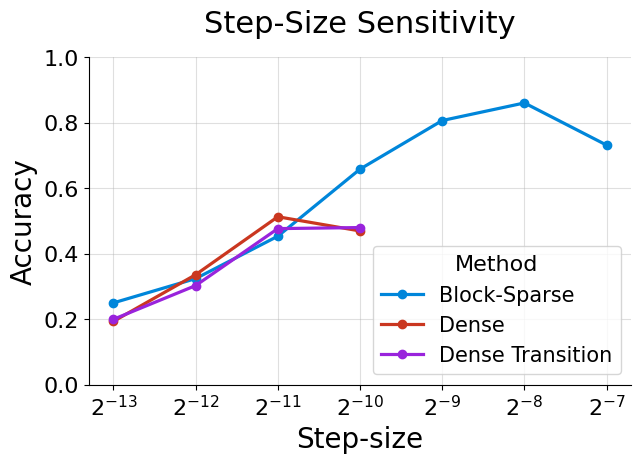

In [23]:
asym = asymptotic_metric(cfg, run, 'accuracy', ['algorithm.transition_step'])
asym['Method'] = asym['algorithm.transition_step'].map(METHOD_LABELS)

set_style('2-col')
fig, ax = plt.subplots()
plot_sensitivity(
    asym, ax=ax, hue_col='Method',
    palette=[PALETTE[m] for m in sorted(asym['Method'].dropna().unique())],
    title='Step-Size Sensitivity', ylabel='Accuracy', ylim=(0, 1),
    legend_title=None)
save_fig(fig_dir='../figures/generated', name='fig3_dense_transition_sensitivity')
plt.show()


# Figure 3b — which direction does the damage

Everything above is unchanged. What follows repeats it with one more arm.

The transition hurts, but a new cross-task connection hurts in two directions
at once. Forward, it feeds another task's signal into a hidden unit and into
an output. Backward, a new `W2` connection returns another task's error to a
hidden unit, so that unit's incoming weights are now trained on a loss that is
not its own.

The **forward-only** arm removes the second one. The connections the flip adds
still run in the forward pass and still learn their own weights; they simply
send no error back into the hidden layer. Whatever degradation survives is the
forward channel, and the gap to the ordinary transition at the same step-size
is the backward one.

Produced by `experiments/sweeps/02_dense_transition/sweep/forward_only.yaml`.
That is not a sweep — it is the two step-sizes Figure 3 already plots the
transition at, 2⁻¹⁰ (the transition's own best) and 2⁻⁸ (block-sparse's), at
the same 30 seeds. Re-run `download_project` in the load cell above before
running this section, or the new sweep will not be in the export.


In [24]:
from multi_mnist.analysis import dedupe_trials

FORWARD_ONLY_SWEEP = '03_dense_transition_forward_only_n16_h256'
FORWARD_ONLY = 'Forward-Only Transition'
FO_COL = 'algorithm.forward_only_distractors'


def add_method_column(cfg):
    """Label each trial by arm.

    The forward-only runs share their `transition_step` with the ordinary
    ones, so the flag has to join the key or the two collapse into one cell.
    Runs from before the flag existed have no column at all.
    """
    out = cfg.copy()
    flag = (out[FO_COL].astype(str).str.lower().isin(['true', '1', '1.0'])
            if FO_COL in out.columns else pd.Series(False, index=out.index))
    out['Method'] = pd.to_numeric(
        out['algorithm.transition_step'], errors='coerce').map(METHOD_LABELS)
    out.loc[flag, 'Method'] = FORWARD_ONLY
    return out


# CELL_COLS with Method standing in for the transition step.
CELL_COLS_FO = ['task.n_tasks', 'model.initial_hidden_units',
                'Method', 'seed_offset', 'optimizer.learning_rate']

# Every method keeps its pinned color. Slot 2 already labels the
# step-size-matched transition curve in Figure 3, so the new arm takes 4.
PALETTE_FO = dict(PALETTE)
PALETTE_FO[FORWARD_ONLY] = get_color_palette()[4]


In [25]:
cfg_fo, run_fo = filter_sweep(
    cfg_all, run_all, SWEEP_NAMES + [FORWARD_ONLY_SWEEP], dedup=False)
cfg_fo = add_method_column(cfg_fo)
cfg_fo, run_fo = dedupe_trials(cfg_fo, run_fo, CELL_COLS_FO)
run_fo['loss_per_task'] = run_fo['loss'] / N_TASKS
print(f'{len(cfg_fo)} trials after dedupe')
print(cfg_fo.groupby(['Method', 'seed_offset']).size())


42 trials after dedupe
Method            seed_offset
Block-Sparse      0.0            7
                  15.0           7
Dense             0.0            7
                  15.0           7
Dense Transition  0.0            7
                  15.0           7
dtype: int64


## Best step-size per method

The forward-only arm only ran at two step-sizes, so its "best" is a choice
between those two rather than a swept optimum.


In [26]:
best_cfg_fo, best_run_fo, best_fo = filter_to_best(
    cfg_fo, run_fo, ['Method'], 'accuracy', direction='max')

summary_fo = best_fo.copy()
summary_fo['step-size'] = summary_fo['optimizer.learning_rate'].apply(
    lambda v: f'2^{int(np.log2(float(v)))}')
print(summary_fo[['Method', 'step-size', '_metric']].to_string(index=False))

assets_fo = fetch_per_seed_arrays(best_cfg_fo['run_id'].tolist(),
                                  cache_dir='data/per_seed_cache')


          Method step-size  _metric
    Block-Sparse      2^-8 0.860443
           Dense     2^-11 0.512681
Dense Transition     2^-10 0.479651


fetch per-seed:   0%|          | 0/6 [00:00<?, ?it/s]

## Figure 3b (left) — learning curves

The four curves of Figure 3, plus the forward-only arm at both of the
step-sizes it was run at. The two transition arms therefore appear at exactly
the same pair of step-sizes, and the vertical gap between the matching pair
after the flip is the backward channel on its own.

The dotted vertical line marks the flip.


fetch per-seed:   0%|          | 0/2 [00:00<?, ?it/s]

fetch per-seed: 0it [00:00, ?it/s]

fetch per-seed: 0it [00:00, ?it/s]

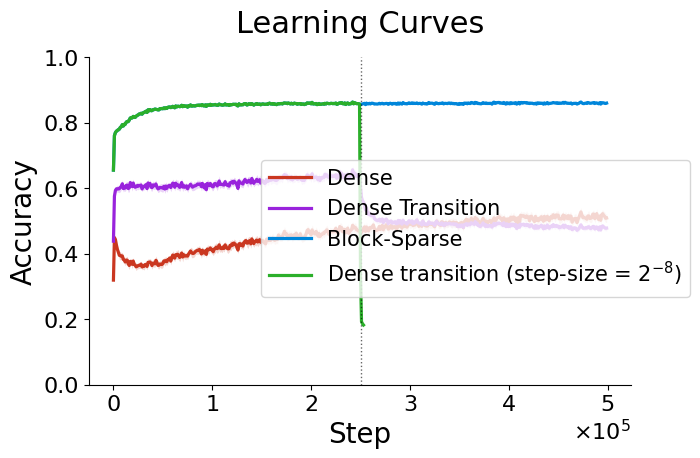

In [27]:
set_style('2-col')
fig, ax = plt.subplots()

# The three fixed-connectivity arms at their own best step-size, exactly as in
# Figure 3. The forward-only arm is not drawn here: it only has two cells, and
# both are drawn below against their dense-transition counterpart.
for fill_step in (0, TRANSITION, NEVER):
    method = METHOD_LABELS[fill_step]
    rids = best_cfg_fo[best_cfg_fo['Method'] == method]['run_id'].tolist()
    _, accs = stack_per_seed(assets_fo, rids)
    if accs is None:
        continue
    plot_ci_curve(np.arange(accs.shape[0]) * 1000, accs,
                  label=method, color=PALETTE_FO[method], ax=ax)

# The two transition arms at the two step-sizes of interest: the ordinary
# transition's own best, and the one that won for block-sparse. Numeric columns
# arrive from the CSV as objects, so coerce before comparing.
lr_bs = float(best_fo.loc[best_fo['Method'] == METHOD_LABELS[NEVER],
                          'optimizer.learning_rate'].iloc[0])
lr_dt = float(best_fo.loc[best_fo['Method'] == METHOD_LABELS[TRANSITION],
                          'optimizer.learning_rate'].iloc[0])
cfg_lr_fo = pd.to_numeric(cfg_fo['optimizer.learning_rate'], errors='coerce')

for method, lr, color, label in [
    (METHOD_LABELS[TRANSITION], lr_bs, get_color_palette()[2], 'Dense transition'),
    (FORWARD_ONLY, lr_dt, PALETTE_FO[FORWARD_ONLY], 'Forward-only transition'),
    (FORWARD_ONLY, lr_bs, get_color_palette()[6], 'Forward-only transition'),
]:
    rids = cfg_fo[(cfg_fo['Method'] == method)
                  & (np.abs(cfg_lr_fo - lr) < lr * 1e-6)]['run_id'].tolist()
    _, accs = stack_per_seed(
        fetch_per_seed_arrays(rids, cache_dir='data/per_seed_cache'), rids)
    if accs is None:
        continue
    plot_ci_curve(np.arange(accs.shape[0]) * 1000, accs, color=color,
                  label=f'{label} (step-size = $2^{{{int(np.log2(lr))}}}$)', ax=ax)

ax.axvline(TRANSITION, linestyle=':', color='black', alpha=0.6, linewidth=1)
ax.set_xlabel('Step'); ax.set_ylabel('Accuracy')
ax.set_title('Learning Curves'); ax.set_ylim(0, 1.0)
ax.ticklabel_format(axis='x', style='sci', scilimits=(0, 0), useMathText=True)
fig.legend(loc='center right')
save_fig(fig_dir='../figures/generated', name='fig3b_forward_only_curves')
plt.show()


## Figure 3b (right) — step-size sensitivity

Figure 3's sensitivity panel with the forward-only arm added. Its line has two
points rather than five, because the arm was only run at the two step-sizes
the curves use — it is there to be read against the dense-transition line at
those two step-sizes, not as a sensitivity curve of its own.


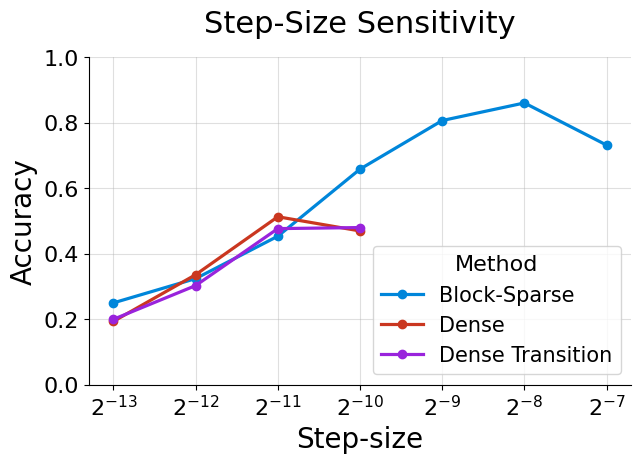

In [28]:
asym_fo = asymptotic_metric(cfg_fo, run_fo, 'accuracy', ['Method'])

set_style('2-col')
fig, ax = plt.subplots()
plot_sensitivity(
    asym_fo, ax=ax, hue_col='Method',
    palette=[PALETTE_FO[m] for m in sorted(asym_fo['Method'].dropna().unique())],
    title='Step-Size Sensitivity', ylabel='Accuracy', ylim=(0, 1),
    legend_title=None)
save_fig(fig_dir='../figures/generated', name='fig3b_forward_only_sensitivity')
plt.show()
